In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve

import joblib

plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/processed/telco_churn_feature_engineered.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [4]:
print(df.shape)

df.info()

(7032, 31)
<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   bool   
 6   Partner_Yes                            7032 non-null   bool   
 7   Dependents_Yes                         7032 non-null   bool   
 8   PhoneService_Yes                       7032 non-null   bool   
 9   MultipleLines_No phone service         7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  Inte

In [5]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

print(X.shape)

print(y.shape)

(7032, 30)
(7032,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)

print("Testing Set :", X_test.shape)

Training Set : (5625, 30)
Testing Set : (1407, 30)


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [8]:
print("="*50)

print("Train Class Distribution")

print(y_train.value_counts())

print("="*50)

Train Class Distribution
Churn
0    4130
1    1495
Name: count, dtype: int64


In [9]:
print("="*50)

print("Test Class Distribution")

print(y_test.value_counts())

print("="*50)

Test Class Distribution
Churn
0    1033
1     374
Name: count, dtype: int64


In [10]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [11]:
logistic_predictions = logistic_model.predict(
    X_test_scaled
)

logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:,1]

In [12]:
print("="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)

print("Accuracy :", accuracy_score(y_test, logistic_predictions))
print("Precision:", precision_score(y_test, logistic_predictions))
print("Recall   :", recall_score(y_test, logistic_predictions))
print("F1 Score :", f1_score(y_test, logistic_predictions))
print("ROC AUC  :", roc_auc_score(y_test, logistic_probabilities))

LOGISTIC REGRESSION RESULTS
Accuracy : 0.8038379530916845
Precision: 0.6475903614457831
Recall   : 0.5748663101604278
F1 Score : 0.6090651558073654
ROC AUC  : 0.8356727976766699


In [13]:
print(classification_report(
    y_test,
    logistic_predictions
))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



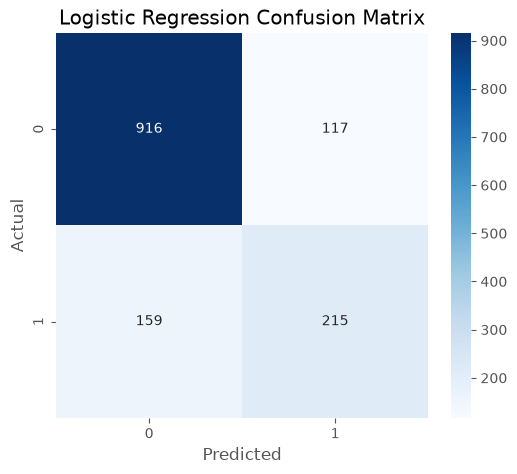

In [14]:
cm = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [16]:
rf_predictions = rf_model.predict(
    X_test
)

rf_probabilities = rf_model.predict_proba(
    X_test
)[:,1]

In [17]:
print("="*60)
print("RANDOM FOREST RESULTS")
print("="*60)

print("Accuracy :", accuracy_score(y_test, rf_predictions))
print("Precision:", precision_score(y_test, rf_predictions))
print("Recall   :", recall_score(y_test, rf_predictions))
print("F1 Score :", f1_score(y_test, rf_predictions))
print("ROC AUC  :", roc_auc_score(y_test, rf_probabilities))

RANDOM FOREST RESULTS
Accuracy : 0.7938877043354655
Precision: 0.64
Recall   : 0.5133689839572193
F1 Score : 0.56973293768546
ROC AUC  : 0.8306979308488336


In [18]:
print(classification_report(
    y_test,
    rf_predictions
))

              precision    recall  f1-score   support

           0       0.84      0.90      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407



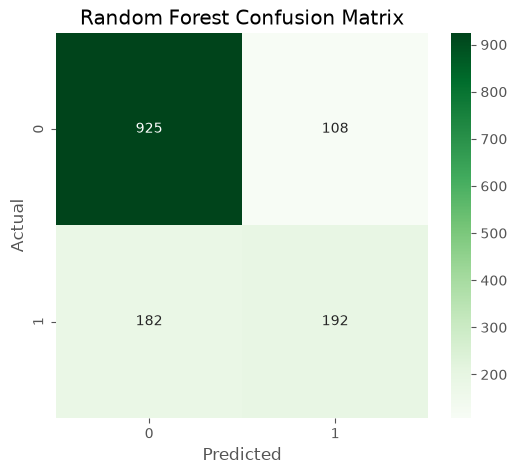

In [19]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [21]:
xgb_predictions = xgb_model.predict(
    X_test
)

xgb_probabilities = xgb_model.predict_proba(
    X_test
)[:,1]

In [22]:
print("="*60)
print("XGBOOST RESULTS")
print("="*60)

print("Accuracy :", accuracy_score(y_test, xgb_predictions))
print("Precision:", precision_score(y_test, xgb_predictions))
print("Recall   :", recall_score(y_test, xgb_predictions))
print("F1 Score :", f1_score(y_test, xgb_predictions))
print("ROC AUC  :", roc_auc_score(y_test, xgb_probabilities))

XGBOOST RESULTS
Accuracy : 0.7846481876332623
Precision: 0.6099071207430341
Recall   : 0.5267379679144385
F1 Score : 0.5652797704447633
ROC AUC  : 0.8227826640644816


In [23]:
print(classification_report(
    y_test,
    xgb_predictions
))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.53      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.78      0.78      0.78      1407



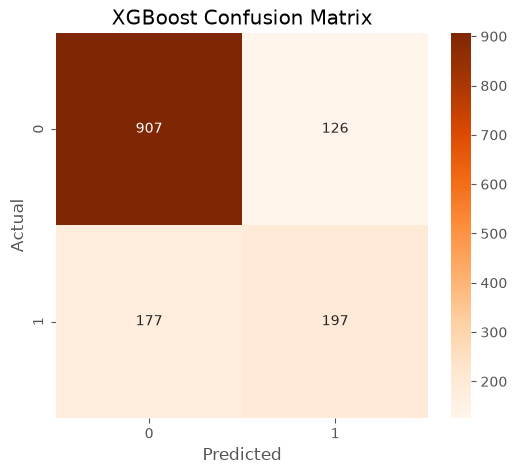

In [24]:
cm = confusion_matrix(
    y_test,
    xgb_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [25]:
models = {
    "Logistic Regression": (
        logistic_model,
        X_train_scaled
    ),
    "Random Forest": (
        rf_model,
        X_train
    ),
    "XGBoost": (
        xgb_model,
        X_train
    )
}

cv_results = []

for model_name, (model, X_data) in models.items():

    scores = cross_val_score(
        model,
        X_data,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Mean CV Accuracy": scores.mean(),
        "Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df

,Model,Mean CV Accuracy,Std
0,Logistic Regression,0.802489,0.012258
1,Random Forest,0.798222,0.011480
2,XGBoost,0.790756,0.011760


In [26]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [8, 10, 12],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 8, 'min_samples_split': 10, 'n_estimators': 300}
0.8457145286548382


In [27]:
best_rf = grid_search.best_estimator_

best_rf_predictions = best_rf.predict(X_test)

best_rf_probabilities = best_rf.predict_proba(X_test)[:,1]

print(classification_report(
    y_test,
    best_rf_predictions
))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [28]:
leaderboard = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, xgb_predictions)
    ],

    "Precision":[
        precision_score(y_test, logistic_predictions),
        precision_score(y_test, rf_predictions),
        precision_score(y_test, xgb_predictions)
    ],

    "Recall":[
        recall_score(y_test, logistic_predictions),
        recall_score(y_test, rf_predictions),
        recall_score(y_test, xgb_predictions)
    ],

    "F1 Score":[
        f1_score(y_test, logistic_predictions),
        f1_score(y_test, rf_predictions),
        f1_score(y_test, xgb_predictions)
    ],

    "ROC AUC":[
        roc_auc_score(y_test, logistic_probabilities),
        roc_auc_score(y_test, rf_probabilities),
        roc_auc_score(y_test, xgb_probabilities)
    ]

})

leaderboard = leaderboard.sort_values(
    "ROC AUC",
    ascending=False
)

leaderboard

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.803838,0.647590,0.574866,0.609065,0.835673
1,Random Forest,0.793888,0.640000,0.513369,0.569733,0.830698
2,XGBoost,0.784648,0.609907,0.526738,0.565280,0.822783


In [29]:
leaderboard.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Metrics saved successfully!")

Metrics saved successfully!


In [30]:
joblib.dump(
    logistic_model,
    "../models/logistic_regression.pkl"
)

joblib.dump(
    rf_model,
    "../models/random_forest.pkl"
)

joblib.dump(
    xgb_model,
    "../models/xgboost.pkl"
)

print("Models saved successfully!")

Models saved successfully!


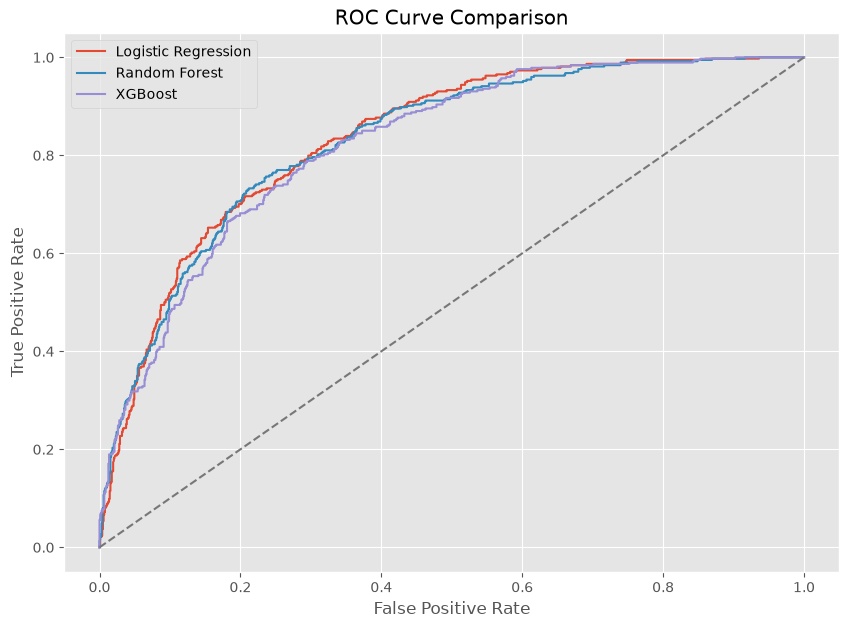

In [31]:
plt.figure(figsize=(10,7))

fpr, tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

fpr, tpr, _ = roc_curve(
    y_test,
    rf_probabilities
)

plt.plot(
    fpr,
    tpr,
    label="Random Forest"
)

fpr, tpr, _ = roc_curve(
    y_test,
    xgb_probabilities
)

plt.plot(
    fpr,
    tpr,
    label="XGBoost"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

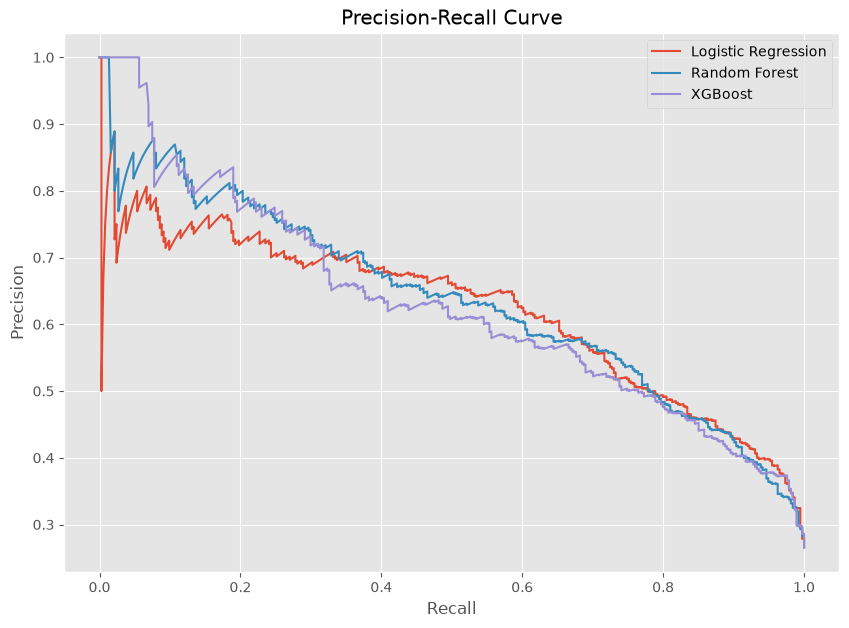

In [32]:
plt.figure(figsize=(10,7))

precision, recall, _ = precision_recall_curve(
    y_test,
    logistic_probabilities
)

plt.plot(
    recall,
    precision,
    label="Logistic Regression"
)

precision, recall, _ = precision_recall_curve(
    y_test,
    rf_probabilities
)

plt.plot(
    recall,
    precision,
    label="Random Forest"
)

precision, recall, _ = precision_recall_curve(
    y_test,
    xgb_probabilities
)

plt.plot(
    recall,
    precision,
    label="XGBoost"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

In [33]:
best_model = leaderboard.iloc[0]

print("="*60)
print("BEST MODEL")
print("="*60)

print(best_model)

BEST MODEL
Model        Logistic Regression
Accuracy                0.803838
Precision                0.64759
Recall                  0.574866
F1 Score                0.609065
ROC AUC                 0.835673
Name: 0, dtype: object


In [34]:
print("="*60)
print("MODEL TRAINING COMPLETED")
print("="*60)

print("Total Models Trained :", len(leaderboard))
print("Best Model :", leaderboard.iloc[0]["Model"])
print("Best ROC AUC :", round(leaderboard.iloc[0]["ROC AUC"],4))

MODEL TRAINING COMPLETED
Total Models Trained : 3
Best Model : Logistic Regression
Best ROC AUC : 0.8357


In [35]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf_model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
1,tenure,0.184203
3,TotalCharges,0.169426
2,MonthlyCharges,0.136148
10,InternetService_Fiber optic,0.059335
25,Contract_Two year,0.051612
28,PaymentMethod_Electronic check,0.049705
13,OnlineSecurity_Yes,0.033418
24,Contract_One year,0.029701
19,TechSupport_Yes,0.024942
26,PaperlessBilling_Yes,0.021939


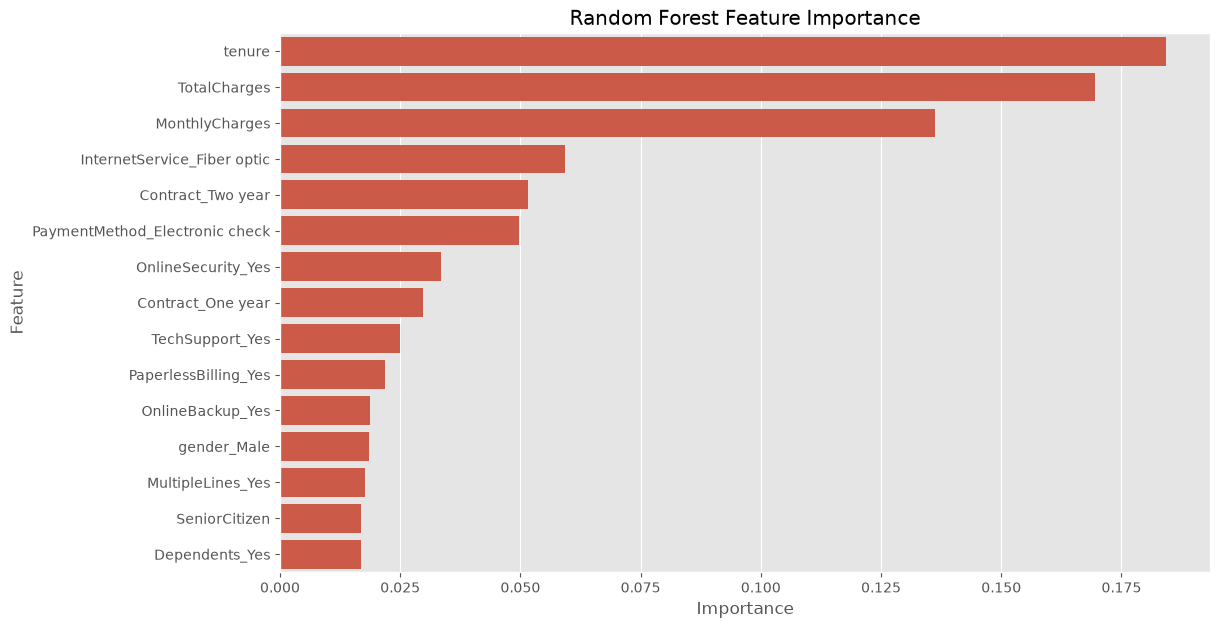

In [36]:
plt.figure(figsize=(12,7))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature"

)

plt.title("Random Forest Feature Importance")

plt.show()

In [37]:
import time

start = time.time()

rf_model.fit(

    X_train,

    y_train

)

end = time.time()

print("Training Time :",end-start,"seconds")

Training Time : 0.7431299686431885 seconds


In [38]:
start = time.time()

rf_model.predict(

    X_test

)

end = time.time()

print("Prediction Time :",end-start,"seconds")

Prediction Time : 0.07276511192321777 seconds


In [39]:
importance.to_csv(

    "../reports/feature_importance.csv",

    index=False

)

print("Feature importance saved.")

Feature importance saved.


In [40]:
import joblib

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!
